In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb # or import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
df = pd.read_csv('train.csv', index_col=False)
print("Columns in DataFrame:", df.columns.tolist())
print("DataFrame shape:", df.shape)

Columns in DataFrame: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
DataFrame shape: (77299, 11)


In [3]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64


In [4]:
if 'Temperature' in df.columns:
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())

# For categorical features
categorical_cols = ['RoadType', 'LargeVehicles', 'Weather', 'Landmarks']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [5]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64


In [6]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,Unknown,1,Not Allowed,No,16.382587,Unknown
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.382587,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [7]:
df[['Hour', 'Minute']] = df['timestamp'].str.split(':', expand=True).astype(int)
df['TimeInMinutes'] = df['Hour'] * 60 + df['Minute']
df['sine_time'] = np.sin(2 * np.pi * df['TimeInMinutes'] / 1440)
df['cosine_time'] = np.cos(2 * np.pi * df['TimeInMinutes'] / 1440)

In [8]:
df['demand_lag_1'] = df.groupby('geohash')['demand'].shift(1)
df['demand_lag_2'] = df.groupby('geohash')['demand'].shift(2)

# Fill the first few empty rows created by the shift
df['demand_lag_1'] = df['demand_lag_1'].fillna(df['demand_lag_1'].median())
df['demand_lag_2'] = df['demand_lag_2'].fillna(df['demand_lag_2'].median())

In [9]:
for col in ['Weather', 'Landmarks']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

In [10]:
columns_to_encode = ['geohash', 'RoadType', 'LargeVehicles']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_matrix = encoder.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(columns_to_encode))

# Combine and drop raw categorical columns
df = df.reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(columns=columns_to_encode)

In [12]:
df.head()

,Index,day,timestamp,demand,NumberofLanes,Landmarks,Temperature,Weather,Hour,Minute,...,geohash_qp0dn5,geohash_qp0dnh,geohash_qp0dnj,geohash_qp0dnn,RoadType_Highway,RoadType_Residential,RoadType_Street,RoadType_Unknown,LargeVehicles_Allowed,LargeVehicles_Not Allowed
0,0,48,0:0,0.048804,1,0,16.382587,4,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,48,0:0,0.118507,3,1,31.104565,3,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2,48,0:0,0.027132,1,0,25.919267,3,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,3,48,0:0,0.003272,1,0,16.382587,1,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,48,0:0,0.010819,1,0,10.803667,1,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [13]:
df = df.drop(columns=['Index'], errors='ignore')

In [14]:
df['RoadType_Residential']

0        0.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
77294    1.0
77295    1.0
77296    1.0
77297    1.0
77298    1.0
Name: RoadType_Residential, Length: 77299, dtype: float64

In [15]:
X = df.drop(columns=['demand', 'timestamp', 'Index'], errors='ignore')
y = df['demand']

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features Shape: {X_train.shape}")
print(f"Validation Features Shape: {X_val.shape}\n")

Training Features Shape: (61839, 1267)
Validation Features Shape: (15460, 1267)



In [17]:
model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.85, 
    colsample_bytree=0.85,     # Take 85% of columns randomly per tree
    random_state=42,
    n_jobs=-1           # Take 85% of rows randomly per tree to combat overfitting
)
print("Training model...")
model.fit(X_train, y_train)

Training model...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [18]:
y_pred = model.predict(X_val)

In [19]:
# Calculating standard regression metrics
mae = metrics.mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_val, y_pred))
r2 = metrics.r2_score(y_val, y_pred)

In [20]:
competition_score = max(0, 100 * r2)

In [21]:
print("\n================ EVALUATION METRICS ================")
print(f"Mean Absolute Error (MAE)        : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE)   : {rmse:.4f}")
print(f"Standard R-squared (R²) Score    : {r2:.4f}")
print(f"CUSTOM COMPETITION ACCURACY SCORE: {competition_score:.4f} / 100")
print("====================================================")


================ EVALUATION METRICS ================
Mean Absolute Error (MAE)        : 0.0196
Root Mean Squared Error (RMSE)   : 0.0289
Standard R-squared (R²) Score    : 0.9587
CUSTOM COMPETITION ACCURACY SCORE: 95.8654 / 100


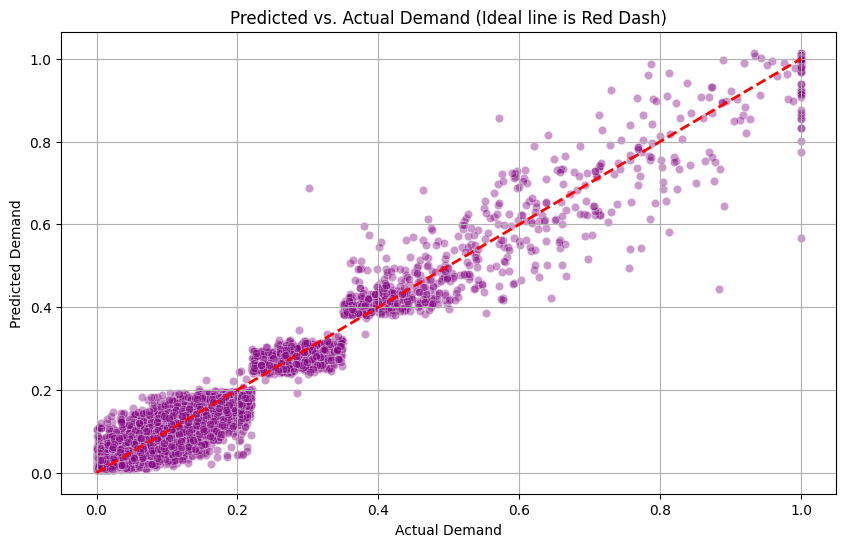

In [22]:
# %%
# Plot 1: Predicted vs. Actual Demand
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.4, color='purple')
# Perfect prediction line
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Predicted vs. Actual Demand (Ideal line is Red Dash)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.grid(True)
plt.show()

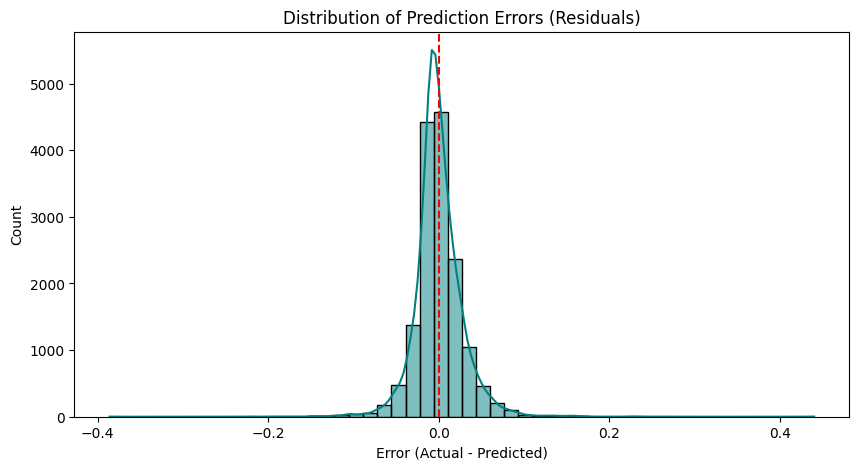

In [23]:
residuals = y_val - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=50, color='teal')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')
plt.show()

In [ ]:
df_test = pd.read_csv('test.csv')

if 'Temperature' in df_test.columns:
    df_test['Temperature'] = df_test['Temperature'].fillna(df_test['Temperature'].median())

# For categorical features
categorical_cols = ['RoadType', 'LargeVehicles', 'Weather', 'Landmarks']
for col in categorical_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('Unknown')


df_test[['Hour', 'Minute']] = df_test['timestamp'].str.split(':', expand=True).astype(int)
df_test['TimeInMinutes'] = df_test['Hour'] * 60 + df_test['Minute']
df_test['sine_time'] = np.sin(2 * np.pi * df_test['TimeInMinutes'] / 1440)
df_test['cosine_time'] = np.cos(2 * np.pi * df_test['TimeInMinutes'] / 1440)

df_test['demand_lag_1'] = df_test.groupby('geohash')['demand'].shift(1)
df_test['demand_lag_2'] = df_test.groupby('geohash')['demand'].shift(2)

# Fill the first few empty rows created by the shift
df_test['demand_lag_1'] = df_test['demand_lag_1'].fillna(df_test['demand_lag_1'].median())
df_test['demand_lag_2'] = df_test['demand_lag_2'].fillna(df_test['demand_lag_2'].median())

for col in ['Weather', 'Landmarks']:
    if col in df_test.columns:
        df_test[col] = df_test[col].astype('category').cat.codes


columns_to_encode = ['geohash', 'RoadType', 'LargeVehicles']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_matrix = encoder.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(columns_to_encode))

# Combine and drop raw categorical columns
df = df.reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(columns=columns_to_encode)